# Task 4 — SMS Spam Detection with Machine Learning

**Objective:** Build an NLP binary classifier that distinguishes spam messages from legitimate (ham) messages.

**Dataset:** UCI SMS Spam Collection — 5,574 labeled messages.  
**Models:** Multinomial Naive Bayes + Linear SVM  
**Features:** TF-IDF  
**Evaluation:** Accuracy, precision, recall, F1-score, confusion matrix

Dataset source: https://archive.ics.uci.edu/dataset/228/sms%2Bspam%2Bcollection


In [1]:
# Uncomment if needed in a fresh environment:
# %pip install pandas scikit-learn matplotlib seaborn nltk wordcloud requests
%pip install requests 
%pip install pandas numpy scikit-learn matplotlib seaborn nltk wordcloud requests
import io
import re
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

print('Dependencies loaded successfully.')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
Using cached scikit_learn-1.9.0-cp312-cp312-win_amd64.whl (8.2 MB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.5 MB/s eta 0:00:01
   ------------------ --------------------- 0.8/1.7 MB 1.7 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 1.9 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp312-cp312-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Matplotlib is building the font cache; this may take a moment.


Dependencies loaded successfully.


In [2]:
UCI_URL = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'

response = requests.get(UCI_URL, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open('SMSSpamCollection') as f:
        df = pd.read_csv(
            f,
            sep='\t',
            header=None,
            names=['label', 'message'],
            encoding='utf-8'
        )

print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Missing values:
label      0
message    0
dtype: int64


,count,percentage
label,,
ham,4825,86.59
spam,747,13.41


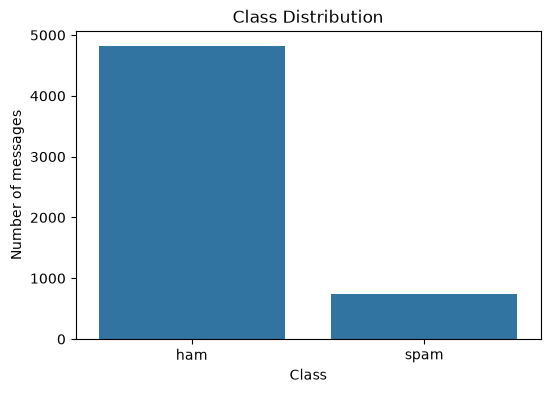

In [3]:
print('Missing values:')
print(df.isna().sum())

class_counts = df['label'].value_counts()
class_percent = df['label'].value_counts(normalize=True).mul(100).round(2)

distribution = pd.DataFrame({
    'count': class_counts,
    'percentage': class_percent
})
display(distribution)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of messages')
plt.show()

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [word for word in text.split()
              if word not in STOP_WORDS and len(word) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].astype(str).apply(preprocess_text)

display(df[['label', 'message', 'clean_message']].head(10))

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,dun say early hor already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,ham,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,spam,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,spam,Had your mobile 11 months or more? U R entitle...,mobile months entitled update latest colour mo...


In [6]:
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print('Training matrix:', X_train_tfidf.shape)
print('Test matrix:', X_test_tfidf.shape)

Training matrix: (4457, 7214)
Test matrix: (1115, 7214)


Train two classifiers

### Model 1 — Multinomial Naive Bayes
Naive Bayes is a strong baseline for text classification because it is fast, simple, and works well with sparse word features.

### Model 2 — Linear Support Vector Machine
A linear SVM is a useful alternative for high-dimensional sparse text data.

In [7]:
nb_model = MultinomialNB(alpha=0.5)
svm_model = LinearSVC(C=1.0, random_state=RANDOM_STATE)

nb_model.fit(X_train_tfidf, y_train)
svm_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
svm_pred = svm_model.predict(X_test_tfidf)

print('Both models trained successfully.')

Both models trained successfully.


In [8]:
def evaluate_model(name, y_true, y_pred):
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='spam'),
        'Recall': recall_score(y_true, y_pred, pos_label='spam'),
        'F1': f1_score(y_true, y_pred, pos_label='spam')
    }
    print(f'--- {name} ---')
    print(classification_report(y_true, y_pred, target_names=['ham', 'spam']))
    return metrics

results = pd.DataFrame([
    evaluate_model('Multinomial Naive Bayes', y_test, nb_pred),
    evaluate_model('Linear SVM', y_test, svm_pred)
]).set_index('Model')

display(results.round(4))

--- Multinomial Naive Bayes ---
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       0.99      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115

--- Linear SVM ---
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.97      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



,Accuracy,Precision,Recall,F1
Model,,,,
Multinomial Naive Bayes,0.9740,0.9918,0.8121,0.8930
Linear SVM,0.9848,0.9714,0.9128,0.9412


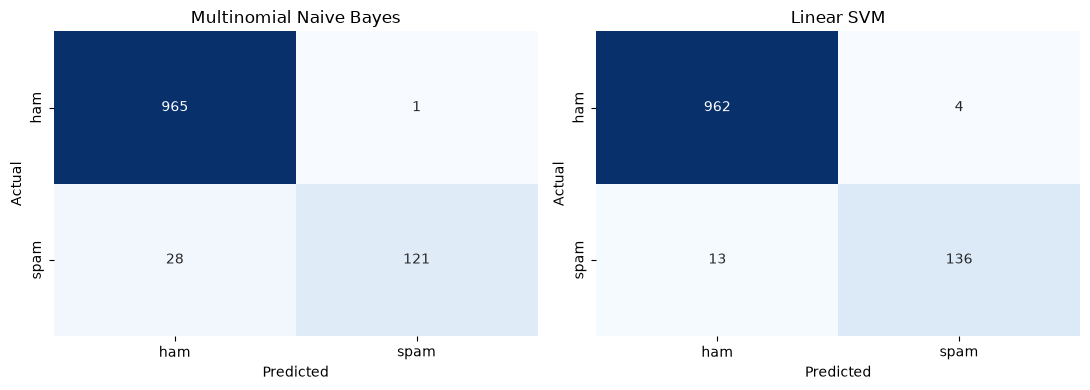

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, predictions) in zip(
    axes,
    [('Multinomial Naive Bayes', nb_pred), ('Linear SVM', svm_pred)]
):
    cm = confusion_matrix(y_test, predictions, labels=['ham', 'spam'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'], ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

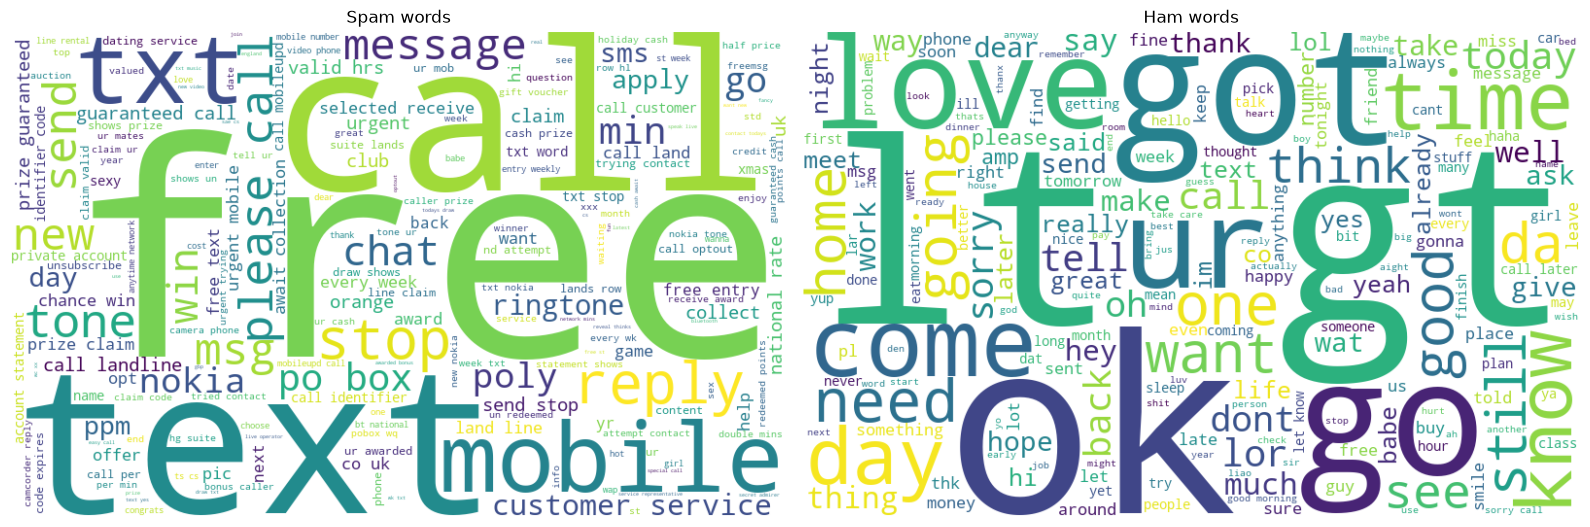

In [10]:
try:
    from wordcloud import WordCloud

    spam_text = ' '.join(df.loc[df['label'] == 'spam', 'clean_message'])
    ham_text = ' '.join(df.loc[df['label'] == 'ham', 'clean_message'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, text, title in zip(
        axes,
        [spam_text, ham_text],
        ['Spam words', 'Ham words']
    ):
        cloud = WordCloud(
            width=800, height=500, background_color='white'
        ).generate(text)
        ax.imshow(cloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

except ImportError:
    print('Bonus skipped: install wordcloud with `pip install wordcloud` and rerun this cell.')

In [11]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = svm_model.coef_[0]

top_spam = feature_names[np.argsort(coefficients)[-20:]][::-1]
top_ham = feature_names[np.argsort(coefficients)[:20]]

print('Top features associated with SPAM:')
print(', '.join(top_spam))

print('\nTop features associated with HAM:')
print(', '.join(top_ham))

Top features associated with SPAM:
txt, mobile, claim, uk, ringtone, reply, win, prize, choose, service, tf, services, com, video, stop, ltd, dating, tone, pobox, apply

Top features associated with HAM:
home, hey, yup, sorry, lt, later, way, mail, want talk, gt, work please, new number, got, ok, road, free call, lt gt, cant, waiting call, friends
